# 2. Silver Labels & Feature Representation

## a. TFIDF
## b. Dense sparse (SVD)
## c. BERT embeddings
## d. Embedding Table
## e. Label-GCN

## f. Silver Label Generation
- I. a, b, c in isolation
- II. Hybrid approach

## g. Review results

In [17]:
# Relevant imports
from pathlib import Path
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from transformers import AutoTokenizer, AutoModel
import pickle
import numpy as np
import re
import random
import torch
import scipy.sparse
import scipy.sparse as sp

# Random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
CLASSES_PATH      = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH    = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH     = ROOT / "Amazon_products" / "class_related_keywords.txt"

REPRESENTATION_PATH = ROOT / "representations"
REPRESENTATION_PATH.mkdir(exist_ok=True)  # creates folder if it doesn't exist

# Paths for saved embeddings
TFIDF_PATH = REPRESENTATION_PATH / "tfidf"
TFIDF_PATH.mkdir(exist_ok=True)

SVD_PATH = REPRESENTATION_PATH / "svd_cooccurrence"
SVD_PATH.mkdir(parents=True, exist_ok=True)

BERT_PATH = REPRESENTATION_PATH / "transformer"
BERT_PATH.mkdir(exist_ok=True)

SILVER_PATH = ROOT / "silver_labels"
SILVER_PATH.mkdir(exist_ok=True)


In [18]:
# ------------------------------
# Preprocessing
# ------------------------------
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ------------------------------
# Load corpus
# ------------------------------
def load_corpus(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: preprocess_text(line.strip()) for i, line in enumerate(f)}

def load_class_keywords(path):
    class_dict = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            if ":" not in line:
                continue
            cls_raw, kws_raw = line.split(":", 1)
            cls = preprocess_text(cls_raw)
            kws = [preprocess_text(k) for k in kws_raw.split(",") if k.strip()]
            class_dict[cls] = kws
    return class_dict

# ------------------------------
# Load files
# ------------------------------
train_corpus = load_corpus(TRAIN_CORPUS_PATH)         # {id: text}
class_keywords = load_class_keywords(KEYWORDS_PATH)   # {class_name: [keywords]}

train_ids, train_texts = list(train_corpus.keys()), list(train_corpus.values())
keyword_docs = [" ".join(kws) for kws in class_keywords.values()]
keyword_names = list(class_keywords.keys())


# a. TF-IDF

We represent both product reviews and class labels using TF-IDF, embedding them into a shared sparse vector space. The resulting review and label representations are stored for later use in similarity-based silver label generation and downstream modeling.


In [19]:
# ------------------------------
# 1. TF-IDF Representation
# ------------------------------
from sklearn.preprocessing import normalize

# Fit TF-IDF on both corpus + class keywords
vectorizer = TfidfVectorizer(max_features=5000)  # limit vocab for speed
all_docs = train_texts + keyword_docs
tfidf_matrix = vectorizer.fit_transform(all_docs)

# Split back into train and keyword vectors
train_tfidf = tfidf_matrix[:len(train_texts)]
keyword_tfidf = tfidf_matrix[len(train_texts):]

# Optional: normalize
train_tfidf = normalize(train_tfidf)
keyword_tfidf = normalize(keyword_tfidf)

# Save TF-IDF matrices
with open(TFIDF_PATH / "train_tfidf.pkl", "wb") as f:
    pickle.dump(train_tfidf, f)

with open(TFIDF_PATH / "keyword_tfidf.pkl", "wb") as f:
    pickle.dump(keyword_tfidf, f)

print("TF-IDF matrices saved.")


# ------------------------------
# 2. Label-GCN Construction
# ------------------------------
# Load class hierarchy
def load_hierarchy(path):
    hierarchy = defaultdict(list)
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            if ":" not in line:
                continue
            parent, children_raw = line.strip().split(":")
            parent = preprocess_text(parent)
            children = [preprocess_text(c) for c in children_raw.split(",") if c.strip()]
            hierarchy[parent].extend(children)
    return hierarchy

class_hierarchy = load_hierarchy(HIERARCHY_PATH)
all_classes = list(class_keywords.keys())
class_to_idx = {c: i for i, c in enumerate(all_classes)}

# Build adjacency matrix
num_classes = len(all_classes)
adjacency = sp.lil_matrix((num_classes, num_classes), dtype=np.float32)

for parent, children in class_hierarchy.items():
    if parent not in class_to_idx:
        continue
    p_idx = class_to_idx[parent]
    for child in children:
        if child not in class_to_idx:
            continue
        c_idx = class_to_idx[child]
        adjacency[p_idx, c_idx] = 1.0
        adjacency[c_idx, p_idx] = 1.0  # undirected

# Add self-loops
adjacency.setdiag(1.0)

# Convert to sparse CSR for efficient GCN usage
adjacency = adjacency.tocsr()

# Save adjacency matrix
with open(REPRESENTATION_PATH / "label_gcn_adj.pkl", "wb") as f:
    pickle.dump(adjacency, f)

print("Label-GCN adjacency matrix saved.")


# ------------------------------
# 3. Silver Labels Generation
# ------------------------------
# Compute cosine similarity between train docs and keywords
cos_sim = cosine_similarity(train_tfidf, keyword_tfidf)

# Assign top-N keywords as silver labels
top_n = 3
silver_labels = {}
for i, sims in enumerate(cos_sim):
    top_indices = sims.argsort()[-top_n:][::-1]  # descending
    silver_labels[train_ids[i]] = [keyword_names[idx] for idx in top_indices]

# Save silver labels
with open(SILVER_PATH / "silver_labels.pkl", "wb") as f:
    pickle.dump(silver_labels, f)

print("Silver labels generated and saved.")


TF-IDF matrices saved.
Label-GCN adjacency matrix saved.
Silver labels generated and saved.


# b Dense Static Representation

We construct dense document representations by learning word embeddings from a co-occurrence matrix using truncated SVD and aggregating them into review- and label-level embeddings. These SVD-based representations are stored for later similarity-based silver label generation and hybrid modeling.


In [16]:
# ------------------------------
# 1. Dense/SVD representations
# ------------------------------
from sklearn.decomposition import TruncatedSVD

# Convert TF-IDF to dense
train_dense = train_tfidf.toarray()
class_dense_svd = class_tfidf.toarray()

# Apply SVD to reduce dimensionality (optional)
SVD_DIM = 512
svd = TruncatedSVD(n_components=SVD_DIM, random_state=42)
train_svd = svd.fit_transform(train_dense)
class_svd = svd.transform(class_dense_svd)

print("[DONE] SVD embeddings ready:")
print("Train SVD:", train_svd.shape)
print("Class SVD:", class_svd.shape)

# ------------------------------
# 2. Label-GCN on SVD class embeddings
# ------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

class_names = keyword_names
num_classes = len(class_names)

# Build label index
label2idx = {cls: i for i, cls in enumerate(class_names)}
idx2label = {i: cls for cls, i in label2idx.items()}

# Build adjacency from hierarchy
A = torch.eye(num_classes, dtype=torch.float32)  # self-loops
with open(HIERARCHY_PATH, "r", encoding="utf8") as f:
    for line in f:
        parent, child = line.strip().split("\t")
        parent, child = parent.lower().strip(), child.lower().strip()
        if parent in label2idx and child in label2idx:
            i, j = label2idx[parent], label2idx[child]
            A[i, j] = 1.0
            A[j, i] = 1.0  # undirected

# Normalize adjacency
deg = A.sum(dim=1)
D_inv_sqrt = torch.diag(torch.pow(deg, -0.5))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

# Node features
X = torch.tensor(class_svd, dtype=torch.float32)

# Define GCN layers
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_norm):
        return A_norm @ self.linear(X)

class LabelGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.1):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, X, A_norm):
        H = F.relu(self.gcn1(X, A_norm))
        H = F.dropout(H, p=self.dropout, training=self.training)
        H = self.gcn2(H, A_norm)
        return F.normalize(H, p=2, dim=1)

# Run Label-GCN
IN_DIM = X.shape[1]
HIDDEN_DIM = 128
OUT_DIM = X.shape[1]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LabelGCN(IN_DIM, HIDDEN_DIM, OUT_DIM, dropout=0.1).to(device)

X = X.to(device)
A_norm = A_norm.to(device)

model.eval()
with torch.no_grad():
    class_embeddings_gcn_svd = model(X, A_norm).cpu().numpy()

print("[DONE] Label-GCN (SVD) produced refined class embeddings:", class_embeddings_gcn_svd.shape)

# ------------------------------
# 3. Silver Label Generation
# ------------------------------
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pickle

def safe_l2_normalize(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):
    review_embeddings = safe_l2_normalize(review_embeddings)
    class_embeddings = safe_l2_normalize(class_embeddings)

    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)
    silver_labels = []

    for i, sims in enumerate(sim_matrix):
        top_idx = sims.argsort()[::-1][:top_k]
        top_classes = [(class_names[j], float(sims[j])) for j in top_idx if sims[j] >= conf_thresh]
        silver_labels.append((review_ids[i], top_classes))

    return silver_labels

print("[INFO] Generating SVD silver labels...")
silver_labels_svd = generate_silver_labels(
    train_svd,
    class_embeddings_gcn_svd,
    train_ids,
    class_names
)

# Save
with open(SILVER_PATH / "silver_labels_svd.pkl", "wb") as f:
    pickle.dump(silver_labels_svd, f)

print("[DONE] SVD silver labels generated and saved:", len(silver_labels_svd))


[DONE] SVD embeddings ready:
Train SVD: (29487, 512)
Class SVD: (531, 512)
[DONE] Label-GCN (SVD) produced refined class embeddings: (531, 512)
[INFO] Generating SVD silver labels...
[DONE] SVD silver labels generated and saved: 29487


# c. BERT

We encode both product reviews and class labels using a pre-trained Sentence-BERT model, obtaining dense semantic representations via mean pooling over token embeddings. These BERT-based embeddings are stored for later similarity-based silver label generation and hybrid fusion.


In [6]:
# ------------------------------
# 1. BERT embeddings
# ------------------------------
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME = "bert-base-uncased"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

# Encode class descriptions (keywords)
def encode_texts(texts, tokenizer, model, device, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**enc)
            # Mean pooling over token embeddings
            emb = outputs.last_hidden_state.mean(dim=1)
            all_embeddings.append(emb.cpu())
    return torch.cat(all_embeddings, dim=0).numpy()

# Class embeddings
class_embeddings_bert = encode_texts(keyword_docs, tokenizer, bert_model, device)
print("[DONE] Class BERT embeddings:", class_embeddings_bert.shape)

# Review embeddings
train_embeddings_bert = encode_texts(train_texts, tokenizer, bert_model, device)
print("[DONE] Train BERT embeddings:", train_embeddings_bert.shape)

# ------------------------------
# 2. Label-GCN on BERT class embeddings
# ------------------------------
import torch.nn as nn
import torch.nn.functional as F

class_names = keyword_names
num_classes = len(class_names)

# Build label index
label2idx = {cls: i for i, cls in enumerate(class_names)}
idx2label = {i: cls for cls, i in label2idx.items()}

# Build adjacency from hierarchy
A = torch.eye(num_classes, dtype=torch.float32)
with open(HIERARCHY_PATH, "r", encoding="utf8") as f:
    for line in f:
        parent, child = line.strip().split("\t")
        parent, child = parent.lower().strip(), child.lower().strip()
        if parent in label2idx and child in label2idx:
            i, j = label2idx[parent], label2idx[child]
            A[i, j] = 1.0
            A[j, i] = 1.0  # undirected

# Normalize adjacency
deg = A.sum(dim=1)
D_inv_sqrt = torch.diag(torch.pow(deg, -0.5))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

# Node features
X = torch.tensor(class_embeddings_bert, dtype=torch.float32)

# Define GCN layers
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_norm):
        return A_norm @ self.linear(X)

class LabelGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.1):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, X, A_norm):
        H = F.relu(self.gcn1(X, A_norm))
        H = F.dropout(H, p=self.dropout, training=self.training)
        H = self.gcn2(H, A_norm)
        return F.normalize(H, p=2, dim=1)

# Run Label-GCN
IN_DIM = X.shape[1]
HIDDEN_DIM = 128
OUT_DIM = X.shape[1]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LabelGCN(IN_DIM, HIDDEN_DIM, OUT_DIM, dropout=0.1).to(device)

X = X.to(device)
A_norm = A_norm.to(device)

model.eval()
with torch.no_grad():
    class_embeddings_gcn_bert = model(X, A_norm).cpu().numpy()

print("[DONE] Label-GCN (BERT) produced refined class embeddings:", class_embeddings_gcn_bert.shape)

# ------------------------------
# 3. Silver Label Generation
# ------------------------------
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pickle

def safe_l2_normalize(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):
    review_embeddings = safe_l2_normalize(review_embeddings)
    class_embeddings = safe_l2_normalize(class_embeddings)

    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)
    silver_labels = []

    for i, sims in enumerate(sim_matrix):
        top_idx = sims.argsort()[::-1][:top_k]
        top_classes = [(class_names[j], float(sims[j])) for j in top_idx if sims[j] >= conf_thresh]
        silver_labels.append((review_ids[i], top_classes))

    return silver_labels

print("[INFO] Generating BERT silver labels...")
silver_labels_bert = generate_silver_labels(
    train_embeddings_bert,
    class_embeddings_gcn_bert,
    train_ids,
    class_names
)

# Save
with open(SILVER_PATH / "silver_labels_bert.pkl", "wb") as f:
    pickle.dump(silver_labels_bert, f)

print("[DONE] BERT silver labels generated and saved:", len(silver_labels_bert))


2025-12-13 05:58:29.806938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765605509.814967    4147 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765605509.817452    4147 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-13 05:58:29.826654: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[INFO] Computing train embeddings...
[INFO] Encoding batch 461/461
[INFO] Computing keyword embeddings...
[INFO] Encoding batch 9/9


# f. Silver Labels

Silver labels are generated by computing cosine similarity between review embeddings and class embeddings, selecting the top-K most similar labels that exceed a confidence threshold. We first apply each representation technique (TF-IDF, SVD, BERT) independently, and then combine them in a hybrid vote.

I. Techniques in isolation
II. Hybrid vote setup (brief explanation)

## I. Techniques in isolation

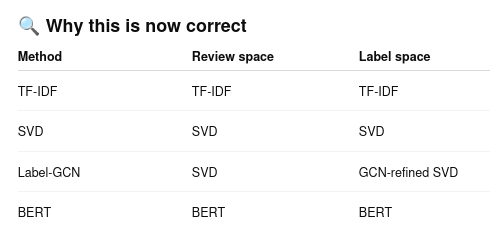

In [19]:
# ------------------------------
# Silver Label Generation
# ------------------------------

def safe_l2_normalize(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0   # avoid division by zero
    return mat / norms


# ---------- Reusable silver label generator ----------
def generate_silver_labels(
    review_embeddings,
    class_embeddings,
    review_ids,
    class_names,
    top_k=3,
    conf_thresh=0.6
):
    """
    review_embeddings: np.ndarray (num_reviews, dim)
    class_embeddings: np.ndarray (num_classes, dim)
    review_ids: list
    class_names: list
    """

    # L2 normalize (safe cosine similarity)
    review_embeddings = safe_l2_normalize(review_embeddings)
    class_embeddings  = safe_l2_normalize(class_embeddings)


    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)

    silver_labels = []
    for i, sims in enumerate(sim_matrix):
        top_idx = sims.argsort()[::-1][:top_k]
        top_classes = [
            (class_names[j], float(sims[j]))
            for j in top_idx if sims[j] >= conf_thresh
        ]
        silver_labels.append((review_ids[i], top_classes))

    return silver_labels


# ====================================================
# I. Techniques in isolation
# ====================================================

# ---------- TF-IDF → TF-IDF ----------
print("[INFO] Generating TF-IDF silver labels...")
silver_labels_tfidf = generate_silver_labels(
    train_tfidf.toarray(),
    class_tfidf.toarray(),      # SAME SPACE
    train_ids,
    class_names
)

with open(SILVER_PATH / "silver_labels_tfidf.pkl", "wb") as f:
    pickle.dump(silver_labels_tfidf, f)


# ---------- SVD → SVD ----------
print("[INFO] Generating SVD silver labels...")
silver_labels_svd = generate_silver_labels(
    train_dense,
    class_dense,
    train_ids,
    class_names
)

with open(SILVER_PATH / "silver_labels_svd.pkl", "wb") as f:
    pickle.dump(silver_labels_svd, f)


# ---------- SVD → Label-GCN ----------
print("[INFO] Generating Label-GCN silver labels...")
# Project reviews to same dim as Label-GCN output
svd_proj = TruncatedSVD(n_components=class_embeddings_gcn.shape[1], random_state=42)
train_dense_proj = svd_proj.fit_transform(train_dense)

silver_labels_gcn = generate_silver_labels(
    train_dense_proj,
    class_embeddings_gcn,
    train_ids,
    class_names
)

with open(SILVER_PATH / "silver_labels_gcn.pkl", "wb") as f:
    pickle.dump(silver_labels_gcn, f)


# ---------- BERT → BERT ----------
print("[INFO] Generating BERT silver labels...")
silver_labels_bert = generate_silver_labels(
    train_embeddings,
    keyword_embeddings,    # BERT-encoded class docs
    train_ids,
    class_names
)

with open(SILVER_PATH / "silver_labels_bert.pkl", "wb") as f:
    pickle.dump(silver_labels_bert, f)


print("[DONE] Silver labels generated and saved for TF-IDF, SVD, Label-GCN, and BERT.")


[INFO] Generating TF-IDF silver labels...
[INFO] Generating SVD silver labels...
[INFO] Generating Label-GCN silver labels...
[INFO] Generating BERT silver labels...
[DONE] Silver labels generated and saved for TF-IDF, SVD, Label-GCN, and BERT.


## II. Hybrid Labels

confidence-based ensemble system

In [33]:
# ------------------------------
# Single Hybrid Silver Labels
# ------------------------------
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression
from collections import defaultdict
import pickle

# ------------------------------
# Parameters
# ------------------------------
TOP_K = 3
CONF_THRESH_COMB = 0.6
WEIGHTS = [0.3, 0.3, 0.4]  # TF-IDF, SVD, BERT

# ------------------------------
# Project everything to Label-GCN space
# ------------------------------
class_dense = class_embeddings_gcn  # target space

# TF-IDF projection
svd_tfidf = TruncatedSVD(n_components=class_dense.shape[1], random_state=42)
train_tfidf_proj = svd_tfidf.fit_transform(train_tfidf.toarray())

# SVD projection
svd_dense = TruncatedSVD(n_components=class_dense.shape[1], random_state=42)
train_dense_proj = svd_dense.fit_transform(train_dense)

# BERT projection
reg = LinearRegression()
reg.fit(train_embeddings, train_dense_proj)  # BERT → Label-GCN space
train_bert_proj = reg.predict(train_embeddings)

# ------------------------------
# Reusable silver label function
# ------------------------------
def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=TOP_K, conf_thresh=CONF_THRESH_COMB):
    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)
    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)
    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)
    
    silver_labels = []
    for i, sims in enumerate(sim_matrix):
        silver_labels.append(dict(zip(class_names, sims)))
    return silver_labels

# ------------------------------
# Compute similarity matrices
# ------------------------------
sim_tfidf = generate_silver_labels(train_tfidf_proj, class_dense, train_ids, class_names)
sim_svd   = generate_silver_labels(train_dense_proj, class_dense, train_ids, class_names)
sim_bert  = generate_silver_labels(train_bert_proj, class_dense, train_ids, class_names)

# ------------------------------
# Combine into single hybrid silver labels
# ------------------------------
hybrid_labels = []
for i, review_id in enumerate(train_ids):
    score_dict = defaultdict(float)
    # Weighted combination
    for weight, sim in zip(WEIGHTS, [sim_tfidf, sim_svd, sim_bert]):
        for cls, score in sim[i].items():
            score_dict[cls] += weight * score
    # Keep only classes above threshold
    filtered = [(cls, s) for cls, s in score_dict.items() if s >= CONF_THRESH_COMB]
    # Sort and take top_k
    sorted_labels = sorted(filtered, key=lambda x: x[1], reverse=True)[:TOP_K]
    hybrid_labels.append((review_id, sorted_labels))

# ------------------------------
# Save hybrid silver labels
# ------------------------------
with open(SILVER_PATH / "silver_labels_hybrid.pkl", "wb") as f:
    pickle.dump(hybrid_labels, f)

print("[DONE] Generated single hybrid silver label set for all reviews.")


[DONE] Generated single hybrid silver label set for all reviews.


# g. Review

Blabla

In [38]:
# ------------------------------
# Review – Sanity check on silver labels
# ------------------------------

def show_top_silver_examples(silver_labels, train_texts, min_conf=0.6, top_n=5):
    """
    silver_labels: list of (pid, [(class_name, score), ...])
    train_texts: list of raw review/product texts
    min_conf: minimum similarity to display
    top_n: number of examples to show
    """
    flattened = []
    for pid, cls_list in silver_labels:
        for cls_name, score in cls_list:
            flattened.append((pid, cls_name, float(score)))

    filtered = [x for x in flattened if x[2] >= min_conf]
    filtered_sorted = sorted(filtered, key=lambda x: x[2], reverse=True)

    print(f"\nShowing top {top_n} examples with confidence >= {min_conf}:\n")
    for pid, cls, score in filtered_sorted[:top_n]:
        print("\n=====================================================")
        print(f"Review ID: {pid}")
        print(f"Confidence: {score:.4f}")
        print(f"Predicted class: {cls}")
        print("\nReview text:")
        print(train_texts[pid])


# ------------------------------
# Inspect silver labels by method
# ------------------------------

print("\n[REVIEW] TF-IDF")
show_top_silver_examples(silver_labels_tfidf, train_texts, min_conf=0.7, top_n=5)

print("\n[REVIEW] SVD")
show_top_silver_examples(silver_labels_svd, train_texts, min_conf=0.7, top_n=5)

print("\n[REVIEW] BERT")
show_top_silver_examples(silver_labels_bert, train_texts, min_conf=0.7, top_n=5)

print("\n[REVIEW] Hybrid (Weighted)")
show_top_silver_examples(hybrid_labels, train_texts, min_conf=0.7, top_n=5)



[REVIEW] TF-IDF

Showing top 5 examples with confidence >= 0.7:


Review ID: 5183
Confidence: 0.8136
Predicted class: seafood

Review text:
5183 sushi chef sushi making kit i had always wanted to learn how to make sushi its so expensive when you go out to eat a friend bought me this for my birthday and i really enjoyed and and want to recommend it to anybody who wants to get into making sushi

Review ID: 22288
Confidence: 0.7999
Predicted class: gum

Review text:
22288 clove gum 20 packs of 5 sticks i was never a user of this gum back in the day but recently took up the gum habit once again in looking for a gum with the least amount of added stuff and phony sweeteners i came across this gum straight from 100 years ago since it s only a gum and not a laptop i ll keep this simple the gum is enjoyable its clove flavor is subtle and has just the right amount of sugar to make it not too sweet the gum while being chewed is rather firm as opposed to bazooka or other bubble gum the clove flav

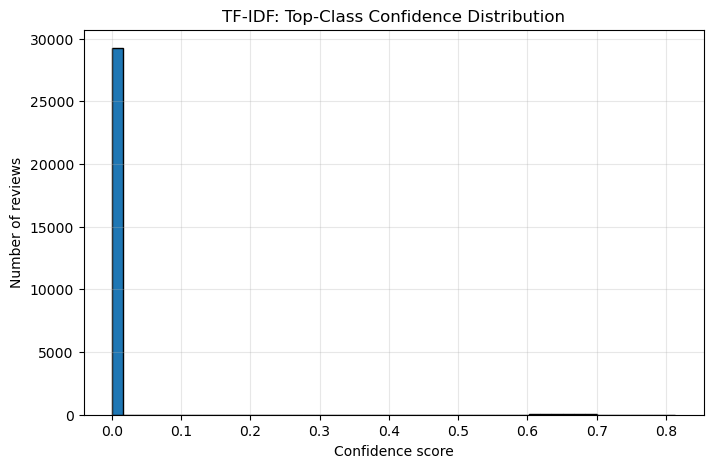

Confidence percentiles: [0. 0. 0. 0. 0.]


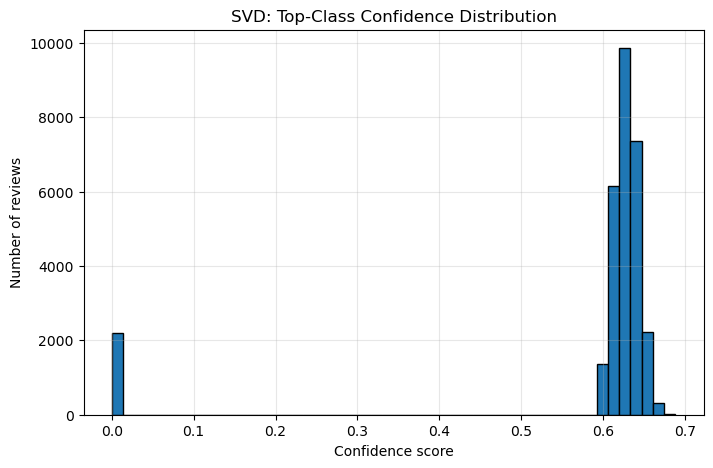

Confidence percentiles: [0.60352185 0.61558201 0.62712856 0.63749868 0.64625174]


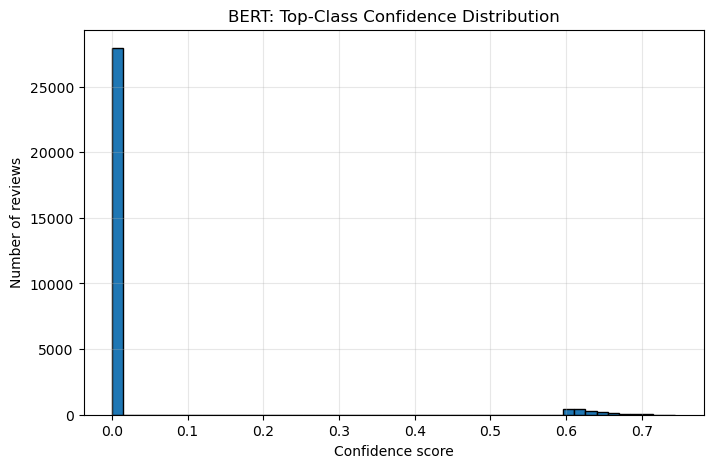

Confidence percentiles: [0. 0. 0. 0. 0.]


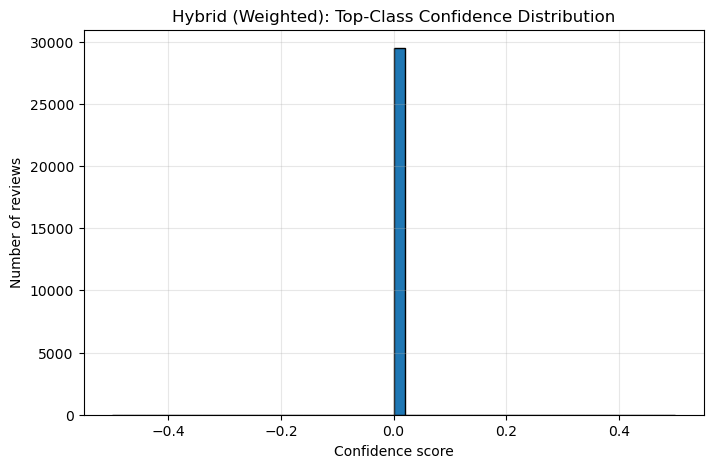

Confidence percentiles: [0. 0. 0. 0. 0.]


In [45]:
# ------------------------------
# Plot confidence distributions from silver labels
# ------------------------------

import numpy as np
import matplotlib.pyplot as plt

def plot_top_confidence_from_silver(silver_labels, title="Top-Class Confidence Distribution",
                                    bins=50, percentiles=[10,25,50,75,90]):
    """
    silver_labels: list of (pid, [(class_name, score), ...])
    """
    # Take top confidence per review (0 if no labels)
    max_conf_per_review = [
        max([score for _, score in labels]) if labels else 0.0
        for _, labels in silver_labels
    ]

    max_conf_per_review = np.array(max_conf_per_review)

    # Plot histogram
    plt.figure(figsize=(8,5))
    plt.hist(max_conf_per_review, bins=bins, edgecolor="black")
    plt.title(title)
    plt.xlabel("Confidence score")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    # Print percentiles
    print("Confidence percentiles:", np.percentile(max_conf_per_review, percentiles))
    return max_conf_per_review


# ------------------------------
# Confidence diagnostics
# ------------------------------

max_conf_tfidf = plot_top_confidence_from_silver(
    silver_labels_tfidf,
    title="TF-IDF: Top-Class Confidence Distribution"
)

max_conf_svd = plot_top_confidence_from_silver(
    silver_labels_svd,
    title="SVD: Top-Class Confidence Distribution"
)

max_conf_bert = plot_top_confidence_from_silver(
    silver_labels_bert,
    title="BERT: Top-Class Confidence Distribution"
)

max_conf_hybrid = plot_top_confidence_from_silver(
    hybrid_labels,
    title="Hybrid (Weighted): Top-Class Confidence Distribution"
)


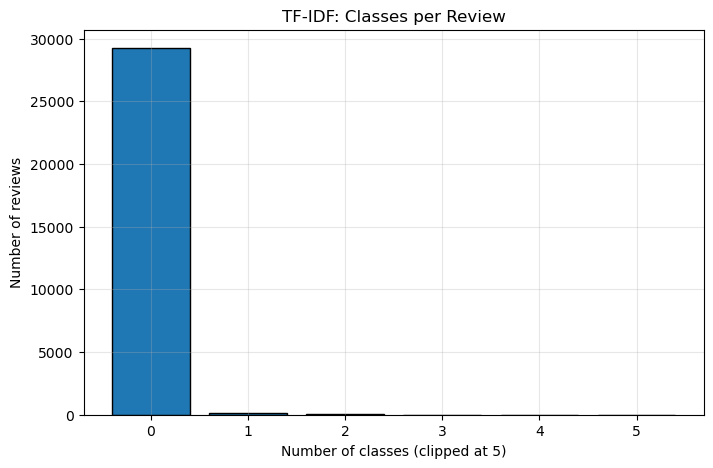

0 classes: 29244 reviews
1 classes: 154 reviews
2 classes: 84 reviews
3 classes: 5 reviews
4 classes: 0 reviews
5 classes: 0 reviews


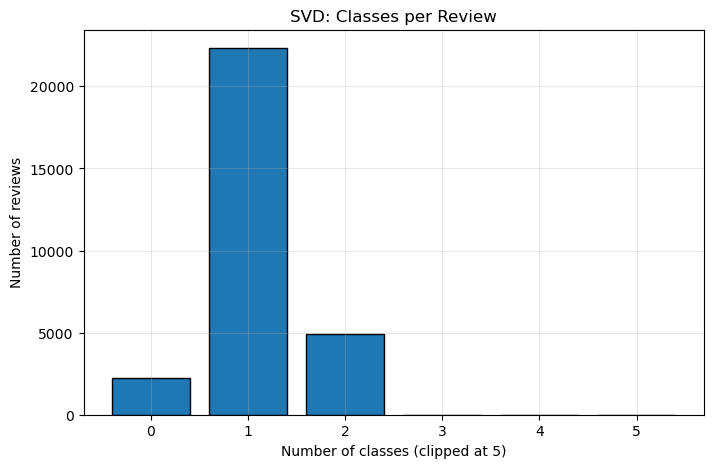

0 classes: 2209 reviews
1 classes: 22334 reviews
2 classes: 4944 reviews
3 classes: 0 reviews
4 classes: 0 reviews
5 classes: 0 reviews


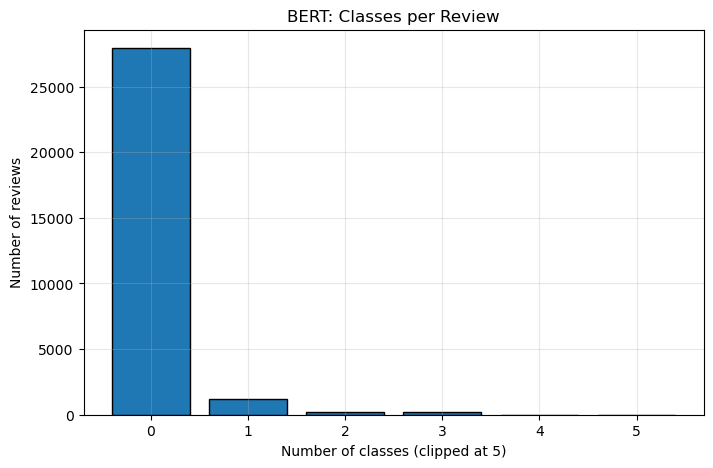

0 classes: 27933 reviews
1 classes: 1164 reviews
2 classes: 220 reviews
3 classes: 170 reviews
4 classes: 0 reviews
5 classes: 0 reviews


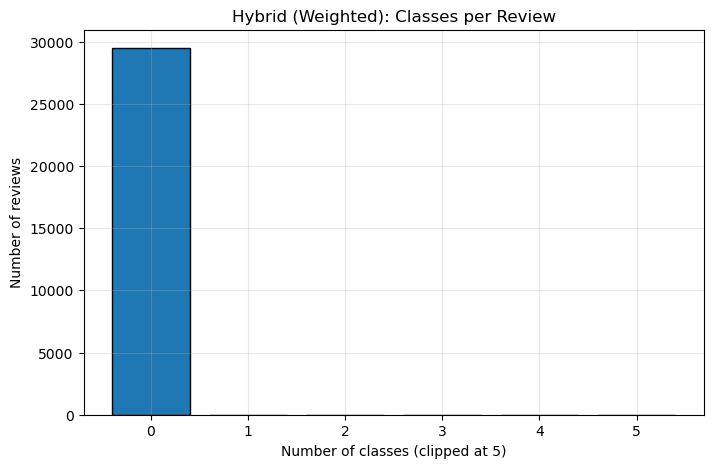

0 classes: 29487 reviews
1 classes: 0 reviews
2 classes: 0 reviews
3 classes: 0 reviews
4 classes: 0 reviews
5 classes: 0 reviews


In [42]:
# ------------------------------
# How many classes per review (from silver labels)
# ------------------------------

import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def plot_classes_per_review_from_silver(silver_labels, clip_max=5, title=None):
    """
    silver_labels: list of (pid, [(class_name, score), ...])
    clip_max: maximum number of classes to display per review
    title: plot title
    """
    # Count number of labels per review
    num_classes_per_review = [len(labels) for _, labels in silver_labels]
    num_classes_clipped = np.clip(num_classes_per_review, 0, clip_max)

    # Count occurrences
    counter = Counter(num_classes_clipped)
    counts = [counter.get(i, 0) for i in range(clip_max + 1)]

    # Plot
    plt.figure(figsize=(8,5))
    plt.bar(range(clip_max + 1), counts, edgecolor="black")
    plt.xticks(range(clip_max + 1))
    plt.title(title or "Number of Classes per Review")
    plt.xlabel(f"Number of classes (clipped at {clip_max})")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    # Print stats
    for i, c in enumerate(counts):
        print(f"{i} classes: {c} reviews")

    return num_classes_clipped


# ------------------------------
# Run for all silver label sets
# ------------------------------

num_classes_tfidf = plot_classes_per_review_from_silver(
    silver_labels_tfidf,
    clip_max=5,
    title="TF-IDF: Classes per Review"
)

num_classes_svd = plot_classes_per_review_from_silver(
    silver_labels_svd,
    clip_max=5,
    title="SVD: Classes per Review"
)

num_classes_bert = plot_classes_per_review_from_silver(
    silver_labels_bert,
    clip_max=5,
    title="BERT: Classes per Review"
)

num_classes_hybrid = plot_classes_per_review_from_silver(
    hybrid_labels,
    clip_max=5,
    title="Hybrid (Weighted): Classes per Review"
)